# 第9章 静学ゲーム：航空会社の参入ゲーム

2社（ANA, JAL）の航空路線への参入ゲームを分析する。
2段階推定法により構造パラメータを推定し、北陸新幹線の反実仮想分析を行う。

## 1. Pythonに関する下準備

In [1]:
import numpy as np
import pandas as pd
from scipy import optimize
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import roc_auc_score, mean_absolute_error
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from patsy import dmatrix
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib
import warnings
import time

warnings.filterwarnings('ignore')

# 日本語フォント設定
for font_name in ['Hiragino Maru Gothic Pro', 'Hiragino Sans',
                   'IPAexGothic', 'Noto Sans CJK JP', 'Yu Gothic']:
    try:
        matplotlib.font_manager.findfont(font_name, fallback_to_default=False)
        plt.rcParams['font.family'] = font_name
        break
    except ValueError:
        continue

# パス設定
base_dir = Path('..')
data_dir = base_dir / 'data'
output_dir = base_dir / 'output'
output_dir.mkdir(exist_ok=True)

print("Setup complete.")


Setup complete.


## 2. データの読み込みと準備

In [2]:
# データの読み込み
y = pd.read_csv(data_dir / 'y.csv')
x_ANA = pd.read_csv(data_dir / 'x_ANA.csv')
x_JAL = pd.read_csv(data_dir / 'x_JAL.csv')
id_port_dyad_long = pd.read_csv(data_dir / 'id_port_dyad_long.csv')

# 二つのデータが同じであることを確認（Flight列以外）
cols_check = [c for c in x_ANA.columns if c != 'Flight']
assert x_ANA[cols_check].equals(x_JAL[cols_check]), "x_ANA and x_JAL differ!"
print("x_ANA and x_JAL (Flight以外) は同一: OK")

# マージ
df = y.copy()
df['id'] = range(1, len(df) + 1)
df['Constant'] = x_ANA['Constant'].values
df['Distance'] = x_ANA['Distance'].values
df['Population'] = x_ANA['Population'].values
df['Pop_Square'] = x_ANA['Pop_Square'].values
df['Train'] = x_ANA['Train'].values
df['Flight_ANA'] = x_ANA['Flight'].values
df['Flight_JAL'] = x_JAL['Flight'].values

print(f"データサイズ: {df.shape}")
df.head()


x_ANA and x_JAL (Flight以外) は同一: OK
データサイズ: (741, 10)


,y_ANA,y_JAL,id,Constant,Distance,Population,Pop_Square,Train,Flight_ANA,Flight_JAL
0,0,0,1,1,0.32420,0.00064,0.00000,0,0.8,0.0
1,0,0,2,1,0.04357,0.00122,0.00000,0,1.3,0.8
2,0,0,3,1,0.18669,0.00450,0.00002,0,0.9,0.7
3,0,0,4,1,0.05165,0.00220,0.00000,0,1.0,1.3
4,0,0,5,1,0.39508,0.00378,0.00001,0,1.6,0.8


## 3. 記述統計

In [3]:
# 記述統計
desc_vars = ['y_ANA', 'y_JAL', 'Distance', 'Population', 'Pop_Square',
             'Train', 'Flight_ANA', 'Flight_JAL']
desc_df = df[desc_vars].describe().loc[['mean', 'std']].T
desc_df.index = ['y_ANA', 'y_JAL', '距離', '人口', '人口2乗',
                 '新幹線', 'フライトANA', 'フライトJAL']
print("記述統計:")
print(desc_df.round(3).to_string())

desc_df.to_csv(output_dir / 'tab9_1_descriptive_statistics.txt', sep='\t')
print("\n保存先: output/tab9_1_descriptive_statistics.txt")


記述統計:
          mean     std
y_ANA    0.144   0.352
y_JAL    0.159   0.366
距離       0.742   0.488
人口       0.824   1.396
人口2乗     2.625  10.167
新幹線      0.108   0.311
フライトANA  3.887   4.238
フライトJAL  3.969   4.129

保存先: output/tab9_1_descriptive_statistics.txt


## 4. 推定

### ステップ1: ノンパラメトリックな確率推定

#### 1. 多項式モデル

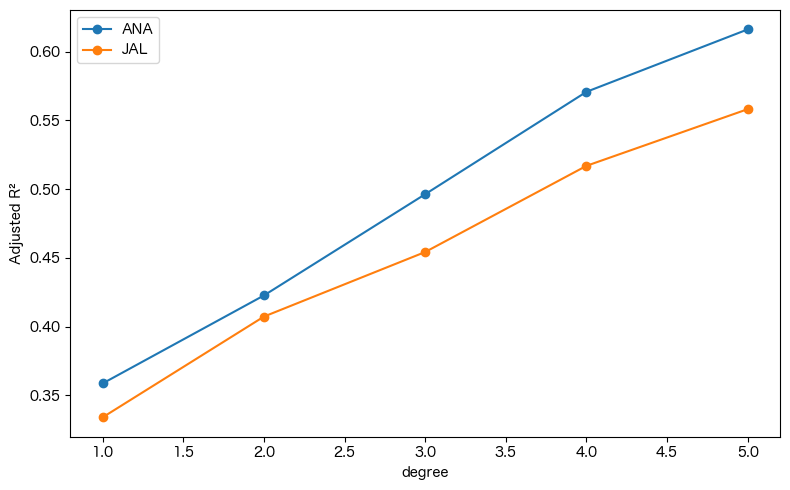

In [4]:
def create_poly_features(df_sub, degree):
    """多項式特徴量をTrain変数との交差項込みで作成する。"""
    base_vars = ['Distance', 'Population', 'Flight_ANA', 'Flight_JAL']
    X_base = df_sub[base_vars].values
    train = df_sub['Train'].values.reshape(-1, 1)

    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_poly = poly.fit_transform(X_base)

    # Train と Train*poly の交差項を追加
    X_train_inter = np.hstack([train, train * X_poly])
    X_all = np.hstack([X_poly, X_train_inter])

    return X_all


# ANA: 多項式次数ごとの決定係数
r_sq_ANA = []
for deg in range(1, 6):
    X = sm.add_constant(create_poly_features(df, deg))
    model = sm.OLS(df['y_ANA'].values, X).fit()
    r_sq_ANA.append({'degree': deg, 'Rsq': model.rsquared_adj})

# JAL: 多項式次数ごとの決定係数
r_sq_JAL = []
for deg in range(1, 6):
    X = sm.add_constant(create_poly_features(df, deg))
    model = sm.OLS(df['y_JAL'].values, X).fit()
    r_sq_JAL.append({'degree': deg, 'Rsq': model.rsquared_adj})

r_sq_df = pd.DataFrame(r_sq_ANA).assign(comp='ANA')
r_sq_df = pd.concat([r_sq_df, pd.DataFrame(r_sq_JAL).assign(comp='JAL')])

fig, ax = plt.subplots(figsize=(8, 5))
for comp, grp in r_sq_df.groupby('comp'):
    ax.plot(grp['degree'], grp['Rsq'], 'o-', label=comp)
ax.set_xlabel('degree')
ax.set_ylabel('Adjusted R²')
ax.legend()
plt.tight_layout()
plt.savefig(output_dir / 'fig_Rsquared.png', dpi=150)
plt.show()


#### 交差検証 (10-fold CV)

In [5]:
# 交差検証
np.random.seed(825)
K = 10
df['k_id'] = np.ceil(np.random.uniform(size=len(df)) * K).astype(int)

print("各フォールドのサイズ:")
print(df['k_id'].value_counts().sort_index())

degrees = [1, 2, 3, 4]

# 格納用
AUCs1 = np.zeros((K, len(degrees)))  # linear polynomial
AUCs2 = np.zeros((K, len(degrees)))  # logit polynomial
MAE1 = np.zeros((K, len(degrees)))
MAE2 = np.zeros((K, len(degrees)))

for i, deg in enumerate(degrees):
    for k in range(1, K + 1):
        train_mask = df['k_id'] != k
        test_mask = df['k_id'] == k

        X_train = sm.add_constant(create_poly_features(df[train_mask], deg))
        X_test = sm.add_constant(create_poly_features(df[test_mask], deg))
        y_train = df.loc[train_mask, 'y_ANA'].values
        y_test = df.loc[test_mask, 'y_ANA'].values

        # Linear
        model1 = sm.OLS(y_train, X_train).fit()
        s1 = np.clip(model1.predict(X_test), 0, 1)

        # Logit
        try:
            model2 = sm.Logit(y_train, X_train).fit(disp=0, method='bfgs', maxiter=200)
            s2 = model2.predict(X_test)
        except Exception:
            s2 = np.full(len(y_test), 0.5)

        # AUC (degree <= 3 only)
        if deg < 4:
            try:
                AUCs1[k-1, i] = roc_auc_score(y_test, s1)
                AUCs2[k-1, i] = roc_auc_score(y_test, s2)
            except ValueError:
                pass

        MAE1[k-1, i] = mean_absolute_error(y_test, s1)
        MAE2[k-1, i] = mean_absolute_error(y_test, s2)

print("多項式CV完了")


各フォールドのサイズ:
k_id
1     76
2     92
3     76
4     75
5     61
6     73
7     70
8     73
9     74
10    71
Name: count, dtype: int64


多項式CV完了


#### 2. B-splineモデル

In [6]:
def create_bspline_features(df_sub, degree, df_full=None):
    """B-spline特徴量をTrain変数との交差項込みで作成する。
    df_full: knot計算に使うデータ（テスト時はトレーニングデータを渡す）
    """
    if df_full is None:
        df_full = df_sub
    base_vars = ['Distance', 'Population', 'Flight_ANA', 'Flight_JAL']
    train = df_sub['Train'].values.reshape(-1, 1)

    # 各変数にB-splineを適用（中央値にknotを1つ置く）
    bs_list = []
    for var in base_vars:
        knot = np.median(df_full[var].values)
        formula = f"bs(x, knots=[{knot}], degree={degree}, include_intercept=False) - 1"
        bs_mat = np.asarray(dmatrix(formula, {"x": df_sub[var].values}))
        bs_list.append(bs_mat)

    X_bs = np.hstack(bs_list)
    # Train との交差項を追加
    X_all = np.hstack([X_bs, train, train * X_bs])

    return X_all


# B-spline CV
degrees_bs = [1, 2, 3]
AUCs1_bs = np.zeros((K, len(degrees_bs)))
AUCs2_bs = np.zeros((K, len(degrees_bs)))
MAE1_bs = np.zeros((K, len(degrees_bs)))
MAE2_bs = np.zeros((K, len(degrees_bs)))

for i, deg in enumerate(degrees_bs):
    for k in range(1, K + 1):
        train_mask = df['k_id'] != k
        test_mask = df['k_id'] == k

        X_train = sm.add_constant(
            create_bspline_features(df[train_mask], deg, df_full=df[train_mask]))
        X_test = sm.add_constant(
            create_bspline_features(df[test_mask], deg, df_full=df[train_mask]))
        y_train = df.loc[train_mask, 'y_ANA'].values
        y_test = df.loc[test_mask, 'y_ANA'].values

        # Linear
        model1 = sm.OLS(y_train, X_train).fit()
        s1 = np.clip(model1.predict(X_test), 0, 1)

        # Logit
        try:
            model2 = sm.Logit(y_train, X_train).fit(disp=0, method='bfgs', maxiter=200)
            s2 = model2.predict(X_test)
        except Exception:
            s2 = np.full(len(y_test), 0.5)

        try:
            AUCs1_bs[k-1, i] = roc_auc_score(y_test, s1)
            AUCs2_bs[k-1, i] = roc_auc_score(y_test, s2)
        except ValueError:
            pass

        MAE1_bs[k-1, i] = mean_absolute_error(y_test, s1)
        MAE2_bs[k-1, i] = mean_absolute_error(y_test, s2)

print("B-spline CV完了")


B-spline CV完了


#### CVの結果まとめ

In [7]:
# AUC
auc_table = pd.DataFrame({
    'd1': [AUCs1[:, 0].mean(), AUCs2[:, 0].mean(),
           AUCs1_bs[:, 0].mean(), AUCs2_bs[:, 0].mean()],
    'd2': [AUCs1[:, 1].mean(), AUCs2[:, 1].mean(),
           AUCs1_bs[:, 1].mean(), AUCs2_bs[:, 1].mean()],
    'd3': [AUCs1[:, 2].mean(), AUCs2[:, 2].mean(),
           AUCs1_bs[:, 2].mean(), AUCs2_bs[:, 2].mean()],
}, index=['Linear', 'Logit', 'Linear spline', 'Logit spline'])

print("AUC:")
print(auc_table.round(3).to_string())
auc_table.round(3).to_csv(output_dir / 'tab_AUC.txt', sep='\t')

# MAE
mae_table = pd.DataFrame({
    'd1': [MAE1[:, 0].mean(), MAE2[:, 0].mean(),
           MAE1_bs[:, 0].mean(), MAE2_bs[:, 0].mean()],
    'd2': [MAE1[:, 1].mean(), MAE2[:, 1].mean(),
           MAE1_bs[:, 1].mean(), MAE2_bs[:, 1].mean()],
    'd3': [MAE1[:, 2].mean(), MAE2[:, 2].mean(),
           MAE1_bs[:, 2].mean(), MAE2_bs[:, 2].mean()],
    'd4': [MAE1[:, 3].mean(), MAE2[:, 3].mean(), np.nan, np.nan],
}, index=['Linear', 'Logit', 'Linear spline', 'Logit spline'])

print("\nMAE:")
print(mae_table.round(3).to_string())
mae_table.round(3).to_csv(output_dir / 'tab_MAE.txt', sep='\t')


AUC:
                  d1     d2     d3
Linear         0.911  0.903  0.836
Logit          0.913  0.892  0.825
Linear spline  0.889  0.858  0.856
Logit spline   0.899  0.879  0.870

MAE:
                  d1     d2     d3     d4
Linear         0.173  0.167  0.158  0.164
Logit          0.150  0.134  0.137  0.500
Linear spline  0.162  0.180  0.174    NaN
Logit spline   0.140  0.149  0.144    NaN


#### ステップ1のモデル推定（全データ）

In [8]:
# 1st stage specification 1: linear degree 1
X_lin = sm.add_constant(create_poly_features(df, 1))

m1st_lin_ANA = sm.OLS(df['y_ANA'].values, X_lin).fit()
m1st_lin_JAL = sm.OLS(df['y_JAL'].values, X_lin).fit()

# 1st stage specification 2: logit with b-spline degree 2
X_bs2_ANA = sm.add_constant(create_bspline_features(df, 2))
X_bs2_JAL = sm.add_constant(create_bspline_features(df, 2))

m1st_logit_spline_ANA = sm.Logit(df['y_ANA'].values, X_bs2_ANA).fit(disp=0, method='bfgs', maxiter=200)
m1st_logit_spline_JAL = sm.Logit(df['y_JAL'].values, X_bs2_JAL).fit(disp=0, method='bfgs', maxiter=200)

# 1st stage specification 3: logit degree 1
m1st_logit_ANA = sm.Logit(df['y_ANA'].values, X_lin).fit(disp=0)
m1st_logit_JAL = sm.Logit(df['y_JAL'].values, X_lin).fit(disp=0)

print("ステップ1の推定完了")
print(f"  Linear ANA R²: {m1st_lin_ANA.rsquared:.4f}")
print(f"  Linear JAL R²: {m1st_lin_JAL.rsquared:.4f}")
print(f"  Logit ANA LogLik: {m1st_logit_ANA.llf:.4f}")
print(f"  Logit JAL LogLik: {m1st_logit_JAL.llf:.4f}")


ステップ1の推定完了
  Linear ANA R²: 0.3664
  Linear JAL R²: 0.3421
  Logit ANA LogLik: -181.5858
  Logit JAL LogLik: -216.4846


In [9]:
# 各モデルで予測値を計算
# linear
p_lin_ANA = m1st_lin_ANA.predict(X_lin)
p_lin_ANA_valid = p_lin_ANA[(p_lin_ANA >= 0) & (p_lin_ANA <= 1)]
p_lin_ANA = np.clip(p_lin_ANA, p_lin_ANA_valid.min(), p_lin_ANA_valid.max())

p_lin_JAL = m1st_lin_JAL.predict(X_lin)
p_lin_JAL_valid = p_lin_JAL[(p_lin_JAL >= 0) & (p_lin_JAL <= 1)]
p_lin_JAL = np.clip(p_lin_JAL, p_lin_JAL_valid.min(), p_lin_JAL_valid.max())

# logit with b-spline
p_logit_sp_ANA = m1st_logit_spline_ANA.predict(X_bs2_ANA)
p_logit_sp_JAL = m1st_logit_spline_JAL.predict(X_bs2_JAL)

# logit
p_logit_ANA = m1st_logit_ANA.predict(X_lin)
p_logit_JAL = m1st_logit_JAL.predict(X_lin)

df['p_lin_ANA'] = p_lin_ANA
df['p_lin_JAL'] = p_lin_JAL
df['p_logit_sp_ANA'] = p_logit_sp_ANA
df['p_logit_sp_JAL'] = p_logit_sp_JAL
df['p_logit_ANA'] = p_logit_ANA
df['p_logit_JAL'] = p_logit_JAL

print("予測確率の計算完了")
print(f"  p_lin_ANA: [{p_lin_ANA.min():.4f}, {p_lin_ANA.max():.4f}]")
print(f"  p_logit_ANA: [{p_logit_ANA.min():.4f}, {p_logit_ANA.max():.4f}]")


予測確率の計算完了
  p_lin_ANA: [0.0009, 0.9975]
  p_logit_ANA: [0.0010, 0.9998]


#### long形式に整理

In [10]:
# ANA行とJAL行に分解してlong形式にする
df_ANA = df.copy()
df_ANA['comp'] = 'ANA'
df_ANA['lin'] = df_ANA['p_lin_ANA']
df_ANA['logit'] = df_ANA['p_logit_ANA']
df_ANA['logit_sp'] = df_ANA['p_logit_sp_ANA']
df_ANA['p_lin_opp'] = df_ANA['p_lin_JAL']
df_ANA['p_logit_opp'] = df_ANA['p_logit_JAL']
df_ANA['p_logit_sp_opp'] = df_ANA['p_logit_sp_JAL']

df_JAL = df.copy()
df_JAL['comp'] = 'JAL'
df_JAL['lin'] = df_JAL['p_lin_JAL']
df_JAL['logit'] = df_JAL['p_logit_JAL']
df_JAL['logit_sp'] = df_JAL['p_logit_sp_JAL']
df_JAL['p_lin_opp'] = df_JAL['p_lin_ANA']
df_JAL['p_logit_opp'] = df_JAL['p_logit_ANA']
df_JAL['p_logit_sp_opp'] = df_JAL['p_logit_sp_ANA']

df_long = pd.concat([df_ANA, df_JAL], ignore_index=True)

print(f"df_long サイズ: {df_long.shape}")


df_long サイズ: (1482, 24)


## 5. ステップ2: 構造パラメータの推定

### 1. 重み付き最小二乗法（OLS）

In [11]:
# Pi (利潤の変換) を作成
eps = 1e-10
df_long['Pi_lin'] = np.log(np.clip(df_long['lin'], eps, 1-eps)) - np.log(1 - np.clip(df_long['lin'], eps, 1-eps))
df_long['Pi_logit'] = np.log(np.clip(df_long['logit'], eps, 1-eps)) - np.log(1 - np.clip(df_long['logit'], eps, 1-eps))
df_long['Pi_logit_sp'] = np.log(np.clip(df_long['logit_sp'], eps, 1-eps)) - np.log(1 - np.clip(df_long['logit_sp'], eps, 1-eps))

# Flight を企業に合わせる
df_long['Flight'] = np.where(df_long['comp'] == 'ANA', df_long['Flight_ANA'], df_long['Flight_JAL'])
df_long['Flight_opp'] = np.where(df_long['comp'] == 'ANA', df_long['Flight_JAL'], df_long['Flight_ANA'])

# 交差項
df_long['Distance_Train'] = df_long['Distance'] * df_long['Train']
df_long['Population_Train'] = df_long['Population'] * df_long['Train']
df_long['Pop_Square_Train'] = df_long['Pop_Square'] * df_long['Train']
df_long['Flight_Train'] = df_long['Flight'] * df_long['Train']

# y変数
df_long['y'] = np.where(df_long['comp'] == 'ANA', df_long['y_ANA'], df_long['y_JAL'])

# OLSで推定 (linear 1st stage)
X_vars_base = ['Constant', 'Distance', 'Population', 'Pop_Square', 'Train', 'Flight',
               'Distance_Train', 'Population_Train', 'Pop_Square_Train', 'Flight_Train']

X_ols_lin = df_long[X_vars_base + ['p_lin_opp']].values
est1_1 = sm.OLS(df_long['Pi_lin'].values, X_ols_lin).fit()

# OLSで推定 (logit 1st stage)
X_ols_logit = df_long[X_vars_base + ['p_logit_opp']].values
est1_2 = sm.OLS(df_long['Pi_logit'].values, X_ols_logit).fit()

# OLSで推定 (logit spline 1st stage)
X_ols_logit_sp = df_long[X_vars_base + ['p_logit_sp_opp']].values
est1_3 = sm.OLS(df_long['Pi_logit_sp'].values, X_ols_logit_sp).fit()

param_names = ['(Intercept)', 'Distance', 'Population', 'Pop_Square', 'Train', 'Flight',
               'Train:Distance', 'Train:Population', 'Train:Pop_Square', 'Train:Flight', 'Delta']

print("OLS推定結果:")
ols_results = pd.DataFrame({
    'linear': est1_1.params,
    'logit': est1_2.params,
    'logit_sp': est1_3.params,
}, index=param_names)
print(ols_results.round(4).to_string())


OLS推定結果:
                   linear    logit  logit_sp
(Intercept)       -3.8652  -3.6736   -6.6921
Distance          -1.4087  -0.7618   -0.2571
Population         0.3039  -0.0770    1.7278
Pop_Square        -0.0729  -0.0042   -0.3583
Train             -5.6386  -4.2589   -9.0326
Flight             0.9267   0.6496    0.7940
Train:Distance    15.2742  11.5268   15.4509
Train:Population   0.4254   0.2368   -0.5605
Train:Pop_Square   0.0335   0.0173    0.2880
Train:Flight      -0.6134  -0.4211   -0.3530
Delta             -7.5963  -2.5270   -2.0063


### 2. GMM推定

In [12]:
def calculate_moment(par, X, Z, y):
    """モーメント条件を計算する。"""
    p = 1 / (1 + np.exp(-X @ par))
    g = Z.T @ (y - p)
    return g


def calculate_standard_error_gmm(par, X, Z, y):
    """GMM標準誤差を計算する。"""
    p = 1 / (1 + np.exp(-X @ par))
    N = X.shape[0]
    K = X.shape[1]

    # Omega
    residuals = (p - y).reshape(-1, 1)
    g_i = Z * residuals  # N x K_z
    Omega = g_i.T @ g_i / N

    # G (ヤコビアン)
    weights = (p * (1 - p)).reshape(-1, 1)
    G = Z.T @ (X * weights) / N

    # 分散
    G_inv = np.linalg.solve(G, np.eye(G.shape[0]))
    V = G_inv @ Omega @ G_inv.T / N

    return np.sqrt(np.diag(V))


# 操作変数行列
Z = df_long[X_vars_base + ['Flight_opp']].values
X_lin_mat = df_long[X_vars_base + ['p_lin_opp']].values
X_logit_mat = df_long[X_vars_base + ['p_logit_opp']].values
X_logit_sp_mat = df_long[X_vars_base + ['p_logit_sp_opp']].values
y_vec = df_long['y'].values

param0 = np.zeros(X_lin_mat.shape[1])

# GMM (not IV)
from scipy.optimize import fsolve

est2_1_gmm = fsolve(lambda x: calculate_moment(x, X_lin_mat, X_lin_mat, y_vec), param0, full_output=True)
est2_2_gmm = fsolve(lambda x: calculate_moment(x, X_logit_mat, X_logit_mat, y_vec), param0, full_output=True)
est2_3_gmm = fsolve(lambda x: calculate_moment(x, X_logit_sp_mat, X_logit_sp_mat, y_vec), param0, full_output=True)

# GMM (IV)
est2_1_gmm2 = fsolve(lambda x: calculate_moment(x, X_lin_mat, Z, y_vec), param0, full_output=True)
est2_2_gmm2 = fsolve(lambda x: calculate_moment(x, X_logit_mat, Z, y_vec), param0, full_output=True)
est2_3_gmm2 = fsolve(lambda x: calculate_moment(x, X_logit_sp_mat, Z, y_vec), param0, full_output=True)

print("GMM推定結果 (IV, logit 1st stage):")
for name, val in zip(param_names, est2_2_gmm2[0]):
    print(f"  {name:20s}: {val:.4f}")


GMM推定結果 (IV, logit 1st stage):
  (Intercept)         : -4.1343
  Distance            : -0.7129
  Population          : 1.5277
  Pop_Square          : -0.2997
  Train               : -5.3285
  Flight              : 0.6012
  Train:Distance      : 12.7582
  Train:Population    : -0.8945
  Train:Pop_Square    : 0.2710
  Train:Flight        : -0.3521
  Delta               : -3.2355


### 3. 最尤推定 (MLE)

In [13]:
# MLE
est3_1 = sm.Logit(y_vec, X_lin_mat).fit(disp=0)
est3_2 = sm.Logit(y_vec, X_logit_mat).fit(disp=0)
est3_3 = sm.Logit(y_vec, X_logit_sp_mat).fit(disp=0)

print("MLE推定結果:")
mle_results = pd.DataFrame({
    'linear': est3_1.params,
    'logit': est3_2.params,
    'logit_sp': est3_3.params,
}, index=param_names)
print(mle_results.round(4).to_string())


MLE推定結果:
                   linear    logit  logit_sp
(Intercept)       -4.0928  -4.1053   -4.0298
Distance          -0.6742  -0.6276   -0.4191
Population         1.5157   1.4961    1.2593
Pop_Square        -0.2983  -0.2958   -0.2565
Train             -4.4878  -4.6453   -3.0388
Flight             0.6268   0.5422    0.3927
Train:Distance    11.9004  11.1866    7.2763
Train:Population  -0.8927  -0.8913   -0.7458
Train:Pop_Square   0.2659   0.2657    0.2247
Train:Flight      -0.3822  -0.3221   -0.2432
Delta             -3.9923  -2.1266    0.8225


### 推定結果のまとめ

In [14]:
def calculate_predict_probability(par, X):
    """予測確率を計算する。"""
    p = 1 / (1 + np.exp(-X @ par))
    return p


def calc_log_likelihood(par, X, y):
    """対数尤度を計算する。"""
    p = calculate_predict_probability(par, X)
    p = np.clip(p, 1e-15, 1 - 1e-15)
    ll = y * np.log(p) + (1 - y) * np.log(1 - p)
    return np.sum(ll)


# 結果をまとめる
jp_names = ['定数', '距離', '人口', '人口2乗', '新幹線', 'フライト',
            '新幹線:距離', '新幹線:人口', '新幹線:人口2乗', '新幹線:フライト', '競争']

results_list = []

# OLS
for label, est, X in [('OLS_linear', est1_1, X_lin_mat),
                       ('OLS_logit', est1_2, X_logit_mat),
                       ('OLS_logit_spline', est1_3, X_logit_sp_mat)]:
    for i, (name, val, se_val) in enumerate(zip(jp_names, est.params, est.bse)):
        results_list.append({'var': name, 'est': val, 'se': se_val,
                             'method': label})

# MLE
for label, est, X in [('MLE_linear', est3_1, X_lin_mat),
                       ('MLE_logit', est3_2, X_logit_mat),
                       ('MLE_logit_spline', est3_3, X_logit_sp_mat)]:
    for i, (name, val, se_val) in enumerate(zip(jp_names, est.params, est.bse)):
        results_list.append({'var': name, 'est': val, 'se': se_val,
                             'method': label})

# GMM
for label, est_res, X in [('Moment_linear', est2_1_gmm, X_lin_mat),
                           ('Moment_logit', est2_2_gmm, X_logit_mat),
                           ('Moment_logit_spline', est2_3_gmm, X_logit_sp_mat)]:
    se_vals = calculate_standard_error_gmm(est_res[0], X, X, y_vec)
    for i, (name, val, se_val) in enumerate(zip(jp_names, est_res[0], se_vals)):
        results_list.append({'var': name, 'est': val, 'se': se_val,
                             'method': label})

# IV GMM
for label, est_res, X in [('IV_Moment_linear', est2_1_gmm2, X_lin_mat),
                           ('IV_Moment_logit', est2_2_gmm2, X_logit_mat),
                           ('IV_Moment_logit_spline', est2_3_gmm2, X_logit_sp_mat)]:
    se_vals = calculate_standard_error_gmm(est_res[0], X, Z, y_vec)
    for i, (name, val, se_val) in enumerate(zip(jp_names, est_res[0], se_vals)):
        results_list.append({'var': name, 'est': val, 'se': se_val,
                             'method': label})

# Log-Likelihood
ll_row = []
for label, params, X in [('OLS_linear', est1_1.params, X_lin_mat),
                           ('OLS_logit', est1_2.params, X_logit_mat),
                           ('OLS_logit_spline', est1_3.params, X_logit_sp_mat),
                           ('MLE_linear', est3_1.params, X_lin_mat),
                           ('MLE_logit', est3_2.params, X_logit_mat),
                           ('MLE_logit_spline', est3_3.params, X_logit_sp_mat),
                           ('Moment_linear', est2_1_gmm[0], X_lin_mat),
                           ('Moment_logit', est2_2_gmm[0], X_logit_mat),
                           ('Moment_logit_spline', est2_3_gmm[0], X_logit_sp_mat),
                           ('IV_Moment_linear', est2_1_gmm2[0], X_lin_mat),
                           ('IV_Moment_logit', est2_2_gmm2[0], X_logit_mat),
                           ('IV_Moment_logit_spline', est2_3_gmm2[0], X_logit_sp_mat)]:
    ll_val = calc_log_likelihood(params, X, y_vec)
    ll_row.append({'method': label, 'LogLik': f"{ll_val:.2f}"})

results_df = pd.DataFrame(results_list)

# ピボットテーブル形式に変換
est_pivot = results_df.pivot_table(index='var', columns='method', values='est')
se_pivot = results_df.pivot_table(index='var', columns='method', values='se')

# OLS linear と MLE logit を中心に表示
display_methods = ['OLS_linear', 'OLS_logit', 'MLE_linear', 'MLE_logit']
print("推定結果 (主要モデル):")
for method in display_methods:
    if method in est_pivot.columns:
        print(f"\n{method}:")
        for var in jp_names:
            if var in est_pivot.index:
                e = est_pivot.loc[var, method]
                s = se_pivot.loc[var, method]
                print(f"  {var:12s}: {e:8.4f} ({s:.4f})")

# 保存
ll_df = pd.DataFrame(ll_row)
print("\n対数尤度:")
print(ll_df.to_string(index=False))

print("\n推定結果をoutput/tab9_2_estimation.txtに保存")
est_pivot.round(4).to_csv(output_dir / 'tab9_2_estimation.txt', sep='\t')


推定結果 (主要モデル):

OLS_linear:
  定数          :  -3.8652 (0.0818)
  距離          :  -1.4087 (0.0776)
  人口          :   0.3039 (0.0890)
  人口2乗        :  -0.0729 (0.0147)
  新幹線         :  -5.6386 (0.2730)
  フライト        :   0.9267 (0.0240)
  新幹線:距離      :  15.2742 (0.6295)
  新幹線:人口      :   0.4254 (0.1514)
  新幹線:人口2乗    :   0.0335 (0.0194)
  新幹線:フライト    :  -0.6134 (0.0264)
  競争          :  -7.5963 (0.4346)

OLS_logit:
  定数          :  -3.6736 (0.0430)
  距離          :  -0.7618 (0.0402)
  人口          :  -0.0770 (0.0467)
  人口2乗        :  -0.0042 (0.0077)
  新幹線         :  -4.2589 (0.1417)
  フライト        :   0.6496 (0.0101)
  新幹線:距離      :  11.5268 (0.3159)
  新幹線:人口      :   0.2368 (0.0799)
  新幹線:人口2乗    :   0.0173 (0.0103)
  新幹線:フライト    :  -0.4211 (0.0130)
  競争          :  -2.5270 (0.1612)

MLE_linear:
  定数          :  -4.0928 (0.2788)
  距離          :  -0.6742 (0.2282)
  人口          :   1.5157 (0.2394)
  人口2乗        :  -0.2983 (0.0459)
  新幹線         :  -4.4878 (1.5665)
  フライト        :   0.6268 (0.06

## 6. 均衡の計算

In [15]:
def calculate_best_response(p_opp, par, X):
    """最適反応を計算する。"""
    X_full = np.column_stack([X, p_opp])
    p = 1 / (1 + np.exp(-X_full @ par))
    return p


def calculate_best_response_opponent(p_opp, par, X):
    """相手プレイヤーの最適反応を計算する。"""
    n_market = X.shape[0] // 2
    p = calculate_best_response(p_opp, par, X)
    p_opp_new = np.concatenate([p[n_market:], p[:n_market]])
    return p_opp_new


def find_equilibrium(p_init, par, X, tol=1e-6, max_iter=1000):
    """最適反応の反復計算で均衡を求める。"""
    n_market = X.shape[0] // 2
    p_opp = np.concatenate([p_init[n_market:], p_init[:n_market]])

    for i in range(max_iter):
        p_opp_new = calculate_best_response_opponent(p_opp, par, X)
        if np.sum((p_opp_new - p_opp)**2) < tol:
            break
        p_opp = p_opp_new

    p_eq = np.concatenate([p_opp[n_market:], p_opp[:n_market]])
    return p_eq


def find_equilibrium_ANA_JAL(ids, optimal, par, df_long_input):
    """ANA/JALの均衡を計算する。"""
    df_sub = df_long_input[df_long_input['id'].isin(ids)].copy()

    X = df_sub[['Constant', 'Distance', 'Population', 'Pop_Square', 'Train', 'Flight',
                'Distance_Train', 'Population_Train', 'Flight_Train', 'Pop_Square_Train']].values

    n_market = X.shape[0] // 2

    if optimal == 'ANA':
        p_init = np.concatenate([np.ones(n_market), np.zeros(n_market)])
    else:
        p_init = np.concatenate([np.zeros(n_market), np.ones(n_market)])

    p_eq = find_equilibrium(p_init, par, X)
    return p_eq


print("均衡計算の関数定義完了")


均衡計算の関数定義完了


In [16]:
# comp列でソート
df_long = df_long.sort_values('comp').reset_index(drop=True)

# IV GMM logit の推定結果を利用
par_gmm = est2_2_gmm2[0]
ids_unique = df['id'].unique()

new_eq_ana = find_equilibrium_ANA_JAL(ids_unique, 'ANA', par_gmm, df_long)
new_eq_jal = find_equilibrium_ANA_JAL(ids_unique, 'JAL', par_gmm, df_long)

df_long['new_eq_ana'] = new_eq_ana
df_long['new_eq_jal'] = new_eq_jal
df_long['dif'] = np.abs(new_eq_ana - new_eq_jal)

print("均衡計算完了")
print(f"  均衡の差 (|ANA - JAL|) の平均: {df_long['dif'].mean():.6f}")
print(f"  均衡の差の最大値: {df_long['dif'].max():.6f}")


均衡計算完了
  均衡の差 (|ANA - JAL|) の平均: 0.000022
  均衡の差の最大値: 0.003549


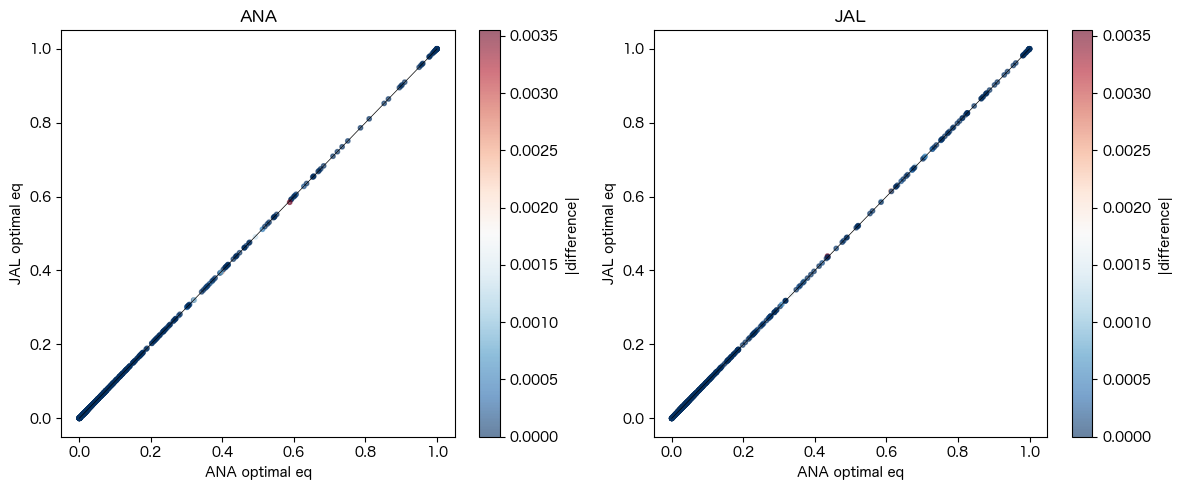

In [17]:
# 複数均衡の確認
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for idx, comp in enumerate(['ANA', 'JAL']):
    mask = df_long['comp'] == comp
    ax = axes[idx]
    sc = ax.scatter(df_long.loc[mask, 'new_eq_ana'],
                    df_long.loc[mask, 'new_eq_jal'],
                    c=df_long.loc[mask, 'dif'], cmap='RdBu_r',
                    vmin=0, vmax=df_long['dif'].max(), s=10, alpha=0.6)
    ax.plot([0, 1], [0, 1], 'k-', linewidth=0.5)
    ax.set_xlabel('ANA optimal eq')
    ax.set_ylabel('JAL optimal eq')
    ax.set_title(comp)
    plt.colorbar(sc, ax=ax, label='|difference|')
plt.tight_layout()
plt.savefig(output_dir / 'fig_equilibrium_multiplicity.png', dpi=150)
plt.show()


## 7. 反実仮想分析: 北陸新幹線

北陸新幹線が開通した場合の航空路線への参入確率の変化を分析する。

In [18]:
# 路線情報をマージ
df_long = df_long.merge(id_port_dyad_long, on='id', how='left')

# 北陸新幹線に関連する空港
hokuriku_ports = ['小松', '富山', '松本', '羽田', '伊丹']

df_long_hokuriku = df_long.copy()
df_long_hokuriku['hokuriku'] = (
    df_long_hokuriku['port1'].isin(hokuriku_ports) &
    df_long_hokuriku['port2'].isin(hokuriku_ports)
).astype(int)

# 反実仮想: 北陸新幹線が通る路線のTrain=1にする
df_long_hokuriku['Train_orig'] = df_long_hokuriku['Train']
df_long_hokuriku['Train'] = np.minimum(1, df_long_hokuriku['Train'] + df_long_hokuriku['hokuriku'])

# 交差項を更新
df_long_hokuriku['Distance_Train'] = df_long_hokuriku['Distance'] * df_long_hokuriku['Train']
df_long_hokuriku['Population_Train'] = df_long_hokuriku['Population'] * df_long_hokuriku['Train']
df_long_hokuriku['Pop_Square_Train'] = df_long_hokuriku['Pop_Square'] * df_long_hokuriku['Train']
df_long_hokuriku['Flight_Train'] = df_long_hokuriku['Flight'] * df_long_hokuriku['Train']

print(f"北陸新幹線関連路線数: {df_long_hokuriku['hokuriku'].sum() // 2}")


北陸新幹線関連路線数: 10


In [19]:
# OLS-logitの推定結果（est1_2）を利用してシミュレーション
par_ols_logit = est1_2.params

# 元の均衡
orig_eq_ana = find_equilibrium_ANA_JAL(ids_unique, 'ANA', par_ols_logit, df_long)
orig_eq_jal = find_equilibrium_ANA_JAL(ids_unique, 'JAL', par_ols_logit, df_long)

# 北陸新幹線後の均衡
hoku_eq_ana = find_equilibrium_ANA_JAL(ids_unique, 'ANA', par_ols_logit, df_long_hokuriku)
hoku_eq_jal = find_equilibrium_ANA_JAL(ids_unique, 'JAL', par_ols_logit, df_long_hokuriku)

df_long_hokuriku['orig_eq_ana'] = orig_eq_ana
df_long_hokuriku['orig_eq_jal'] = orig_eq_jal
df_long_hokuriku['hoku_eq_ana'] = hoku_eq_ana
df_long_hokuriku['hoku_eq_jal'] = hoku_eq_jal

print("反実仮想分析の均衡計算完了")


反実仮想分析の均衡計算完了


In [20]:
# 北陸新幹線関連路線の結果
cf_result = df_long_hokuriku[df_long_hokuriku['hokuriku'] == 1].copy()

# 路線ごとの結果
cf_table = cf_result[['dyad', 'comp', 'orig_eq_ana', 'hoku_eq_ana']].copy()
cf_table = cf_table.rename(columns={'orig_eq_ana': '北陸新幹線なし', 'hoku_eq_ana': '北陸新幹線あり'})

cf_pivot = cf_table.pivot_table(
    index='dyad',
    columns='comp',
    values=['北陸新幹線なし', '北陸新幹線あり']
)

print("反実仮想分析の結果（北陸新幹線関連路線）:")
print(cf_pivot.round(3).to_string())

# 保存
cf_pivot.round(3).to_csv(output_dir / 'tab9_3_counter_factual.txt', sep='\t')
print("\n保存先: output/tab9_3_counter_factual.txt")


反実仮想分析の結果（北陸新幹線関連路線）:
      北陸新幹線あり        北陸新幹線なし       
comp      ANA    JAL     ANA    JAL
dyad                               
伊丹_富山   0.271  0.366   0.426  0.556
伊丹_松本   0.089  0.295   0.218  0.702
富山_松本   0.001  0.001   0.036  0.026
小松_伊丹   0.191  0.373   0.404  0.684
小松_富山   0.000  0.001   0.006  0.027
小松_松本   0.002  0.002   0.041  0.037
小松_羽田   0.989  0.973   0.996  0.990
羽田_伊丹   0.000  0.000   0.000  0.000
羽田_富山   0.998  0.993   1.000  0.999
羽田_松本   0.788  0.619   0.788  0.619

保存先: output/tab9_3_counter_factual.txt


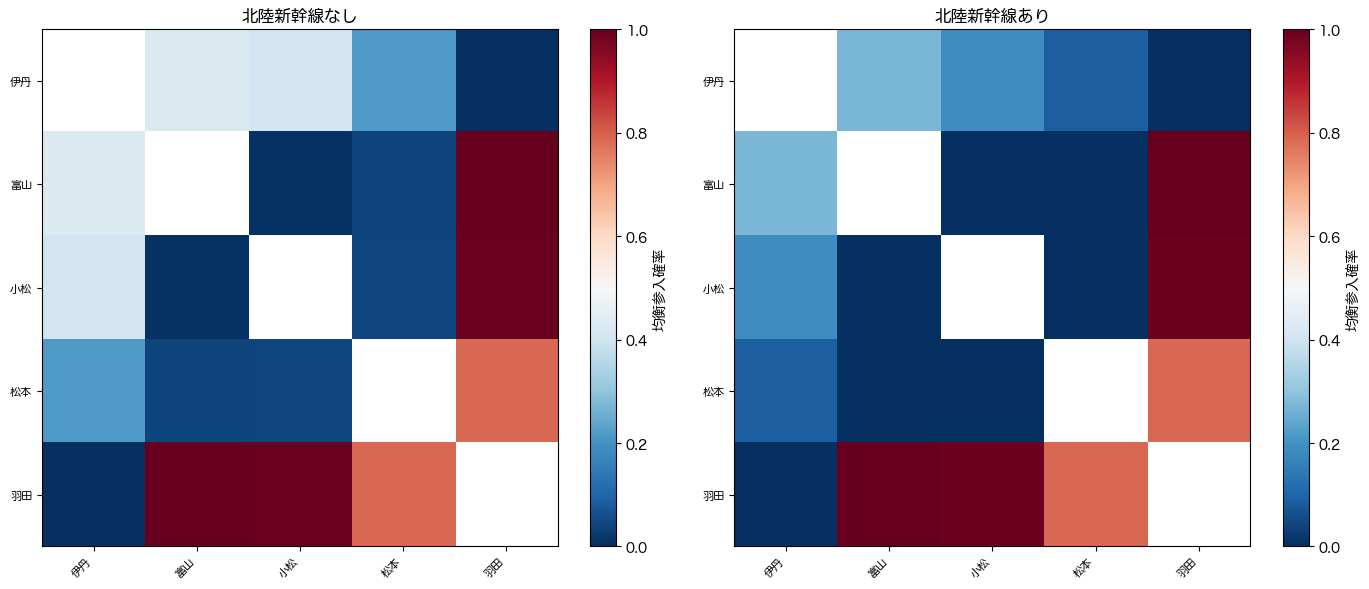

In [21]:
# ヒートマップの作成
cf_hoku = df_long_hokuriku[df_long_hokuriku['hokuriku'] == 1].copy()

# ANA行のみで表示
cf_ana = cf_hoku[cf_hoku['comp'] == 'ANA'].copy()

if len(cf_ana) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    for idx, (col, title) in enumerate([
        ('orig_eq_ana', '北陸新幹線なし'),
        ('hoku_eq_ana', '北陸新幹線あり')
    ]):
        # ピボットテーブルを作成
        ports_in_data = list(set(cf_ana['port1'].tolist() + cf_ana['port2'].tolist()))
        ports_in_data.sort()

        pivot_data = pd.DataFrame(index=ports_in_data, columns=ports_in_data, dtype=float)
        for _, row in cf_ana.iterrows():
            pivot_data.loc[row['port1'], row['port2']] = row[col]
            pivot_data.loc[row['port2'], row['port1']] = row[col]

        ax = axes[idx]
        im = ax.imshow(pivot_data.values.astype(float), cmap='RdBu_r',
                       vmin=0, vmax=1, aspect='auto')
        ax.set_xticks(range(len(ports_in_data)))
        ax.set_xticklabels(ports_in_data, rotation=45, ha='right', fontsize=8)
        ax.set_yticks(range(len(ports_in_data)))
        ax.set_yticklabels(ports_in_data, fontsize=8)
        ax.set_title(title)
        plt.colorbar(im, ax=ax, label='均衡参入確率')

    plt.tight_layout()
    plt.savefig(output_dir / 'fig_hokuriku_heatmap.png', dpi=150)
    plt.show()
else:
    print("北陸新幹線関連路線のデータが見つかりませんでした")


## 8. まとめ

In [22]:
print("=" * 60)
print("第9章の分析完了")
print("=" * 60)
print("\n出力ファイル:")
for f in sorted(output_dir.glob('*')):
    print(f"  {f.name}")


第9章の分析完了

出力ファイル:
  fig_Rsquared.pdf
  fig_Rsquared.png
  fig_equilibrium_multiplicity.pdf
  fig_equilibrium_multiplicity.png
  fig_first_stage.pdf
  fig_flight_probability.pdf
  fig_hokuriku_heatmap.pdf
  fig_hokuriku_heatmap.png
  fig_model_fit.pdf
  tab9_1_descriptive_statistics.txt
  tab9_2_estimation.txt
  tab9_3_counter_factual.txt
  tab_AIC.txt
  tab_AUC.txt
  tab_BIC.txt
  tab_MAE.txt
  tab_counter_factual.txt
  tab_estimation.txt
  tab_result_MLE.txt
  tab_result_OLS_MLE_Eng.txt
  tab_result_OLS_MLE_Jpn.txt
  tab_result_linear_logit.txt
  tab_result_linear_logit_spline.txt
